Project 2: Exploratory Data Analysis (EDA)
Dataset: E-commerce Sales Dataset
Intern: Md Zulkar Nain
Organization: DecodeLabs

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

<Figure size 1000x600 with 0 Axes>

In [4]:
df = pd.read_csv(r"C:\Users\Zulkarnain Yawar\OneDrive\Desktop\Project_2_EDA\raw_dataset.csv")
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [5]:
df.shape

(1200, 14)

In [6]:
df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 non-null   object 
 8   OrderStatus      1200 non-null   object 
 9   TrackingNumber   1200 non-null   object 
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       891 non-null    object 
 12  ReferralSource   1200 non-null   object 
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), object(10)
memory usage: 131.4+ KB


In [9]:
df.describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


In [10]:
df.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [11]:
df['CouponCode'] = df['CouponCode'].fillna('No Coupon')

In [12]:
df.isnull().sum()

OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df['Date'] = pd.to_datetime(df['Date'])

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       1200 non-null   object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

In [16]:
df.to_csv("cleaned_dataset.csv", index=False)


##Exploratory Data Analysis

In [17]:
df[['Quantity','UnitPrice','TotalPrice']].describe()

,Quantity,UnitPrice,TotalPrice
count,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,1053.968300
std,1.407557,197.177146,819.856558
min,1.000000,11.390000,11.390000
25%,2.000000,186.062500,410.520000
50%,3.000000,364.210000,823.615000
75%,4.000000,521.570000,1578.475000
max,5.000000,699.930000,3456.400000


##Product-wise Revenue Analysis

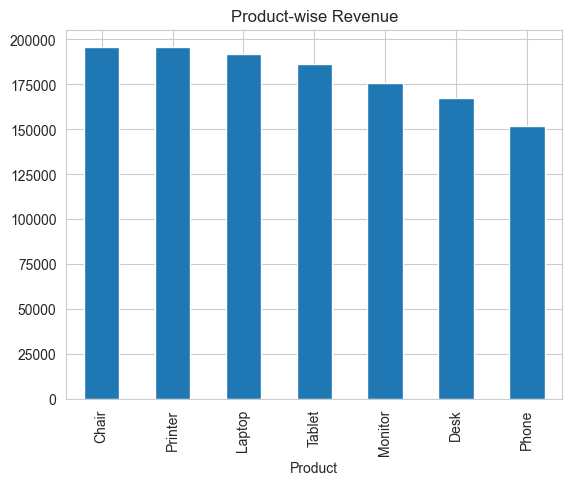

In [18]:
product_sales = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False)

product_sales.plot(kind='bar')
plt.title("Product-wise Revenue")
plt.show()

##Order Status Analysis

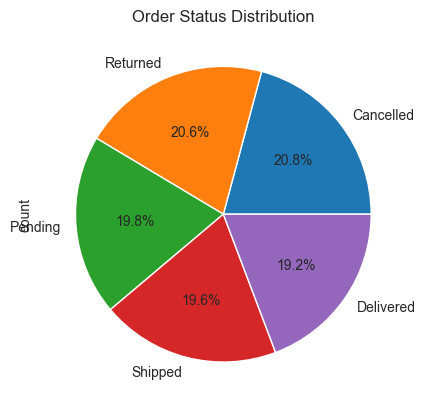

In [19]:
df['OrderStatus'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Order Status Distribution")
plt.show()

##Payment Method Analysis

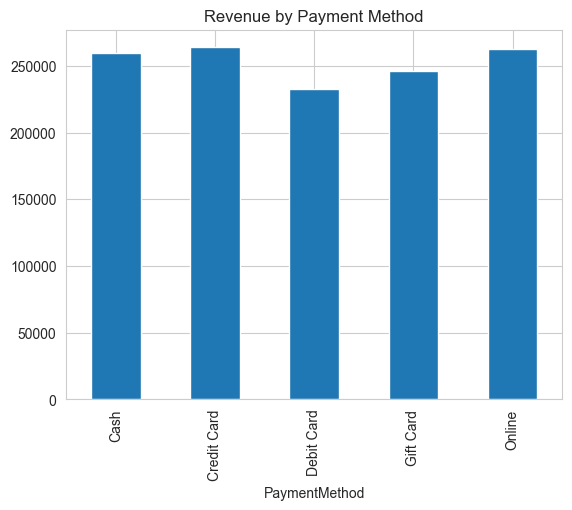

In [20]:
df.groupby('PaymentMethod')['TotalPrice'].sum().plot(kind='bar')
plt.title("Revenue by Payment Method")
plt.show()

##Referral Source Analysis

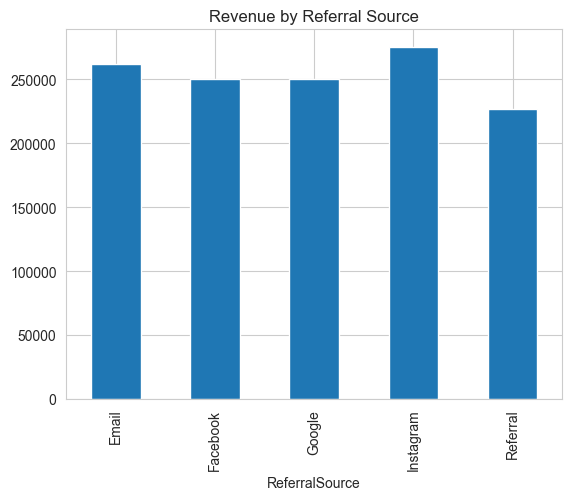

In [21]:
df.groupby('ReferralSource')['TotalPrice'].sum().plot(kind='bar')
plt.title("Revenue by Referral Source")
plt.show()

##Coupon Code Analysis

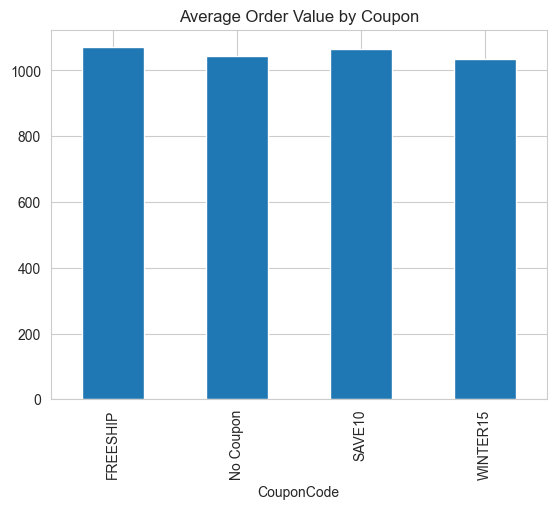

In [22]:
df.groupby('CouponCode')['TotalPrice'].mean().plot(kind='bar')
plt.title("Average Order Value by Coupon")
plt.show()

##Outlier Detection

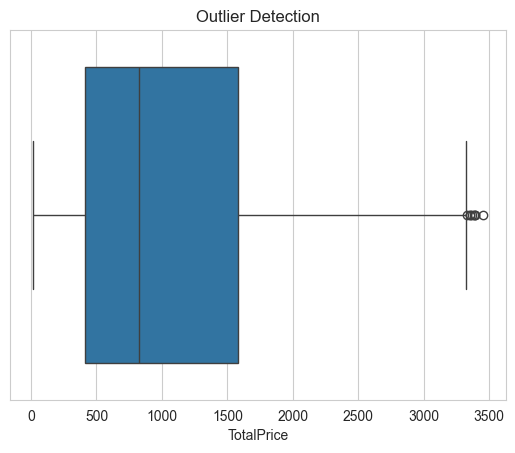

In [23]:
sns.boxplot(x=df['TotalPrice'])
plt.title("Outlier Detection")
plt.show()

##Distribution Analysis

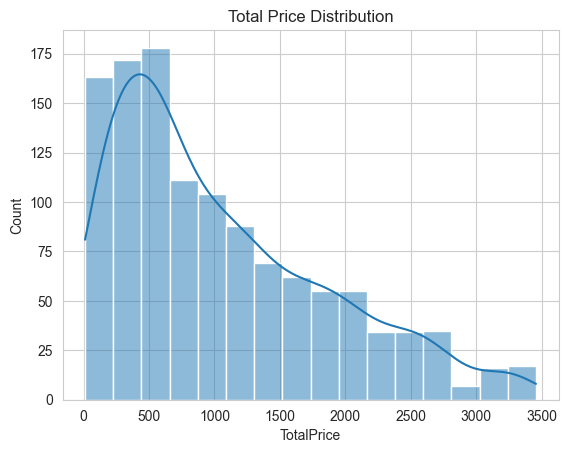

In [24]:
sns.histplot(df['TotalPrice'], kde=True)
plt.title("Total Price Distribution")
plt.show()

##Correlation Heatmap

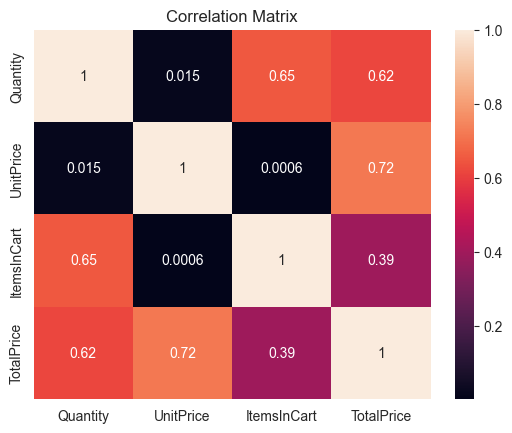

In [25]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

##Time Trend Analysis

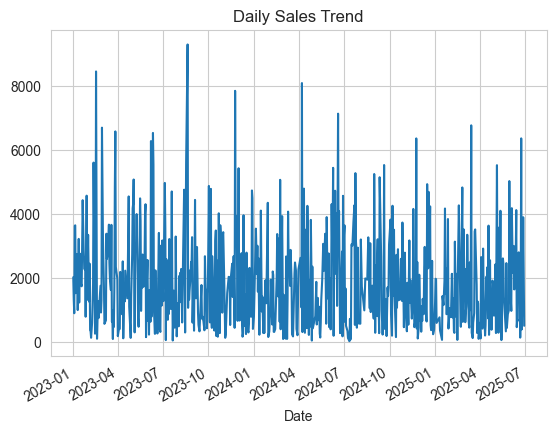

In [26]:
daily_sales = df.groupby('Date')['TotalPrice'].sum()

daily_sales.plot()
plt.title("Daily Sales Trend")
plt.show()

#Key Insights

##1.chair generated highest revenue.

##2.Instagram is the strongest referral source.

##3.Credit card is the preferred payment method.

##4.Some extreme high-value orders exist.

##5.Sales show fluctuations over time.